# EDA — `lexdata.medidas_icbf`
ICBF · Medidas de protección a NNA

## 0 · Setup

In [1]:
# ── Dependencias ────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# ── Estilo ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Conexión PostgreSQL via .env ─────────────────────────────────────────────
load_dotenv()  # carga .env desde la carpeta del notebook
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

def sql(query, **kwargs):
    with engine.connect() as con:
        return pd.read_sql(text(query), con, **kwargs)

print("✅ Conexión lista:", DB_URL.split("@")[-1])


✅ Conexión lista: localhost:5432/lexdata


## 1 · Vista general

In [2]:
df = sql("SELECT * FROM lexdata.medidas_icbf")
print(f"Shape: {df.shape}")
df.head(10)


Shape: (112, 8)


,id,municipio,departamento,anio,cantidad,tipo_ciclo,fuente,created_at
0,1,ANORI,ANTIOQUIA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
1,2,BRICENO,ANTIOQUIA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
2,3,CACERES,ANTIOQUIA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
3,4,ITUANGO,ANTIOQUIA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
4,5,TARAZA,ANTIOQUIA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
5,6,ARAUQUITA,ARAUCA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
6,7,CANTAGALLO,BOLIVAR,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
7,8,SAN PABLO,BOLIVAR,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
8,9,SANTA ROSA DEL SUR,BOLIVAR,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371
9,10,BELEN DE LOS ANDAQUIES,CAQUETA,None,1.0,MEDIDAS_PROTECCION,ICBF — Medidas de Proteccion (v4pt-rnn9),2026-05-25 14:21:48.421371


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,112.0,NaN,NaN,NaN,56.5,1.0,28.75,56.5,84.25,112.0,32.475632
municipio,112,55,PUERTO RICO,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,112,14,CAQUETA,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,112.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
tipo_ciclo,112,1,MEDIDAS_PROTECCION,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente,112,1,ICBF — Medidas de Proteccion (v4pt-rnn9),112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,112,NaN,NaN,NaN,2026-05-25 14:22:27.936016896,2026-05-25 14:21:48.421371,2026-05-25 14:21:48.421370880,2026-05-25 14:22:27.936017408,2026-05-25 14:23:07.450663936,2026-05-25 14:23:07.450664,NaN


## 2 · Nulos

In [4]:
nulos = df.isnull().sum().rename("nulos")
pct   = (df.isnull().mean() * 100).round(2).rename("pct_%")
display(pd.concat([nulos, pct], axis=1))


,nulos,pct_%
id,0,0.0
municipio,0,0.0
departamento,0,0.0
anio,112,100.0
cantidad,0,0.0
tipo_ciclo,0,0.0
fuente,0,0.0
created_at,0,0.0


## 4 · Top 20 municipios

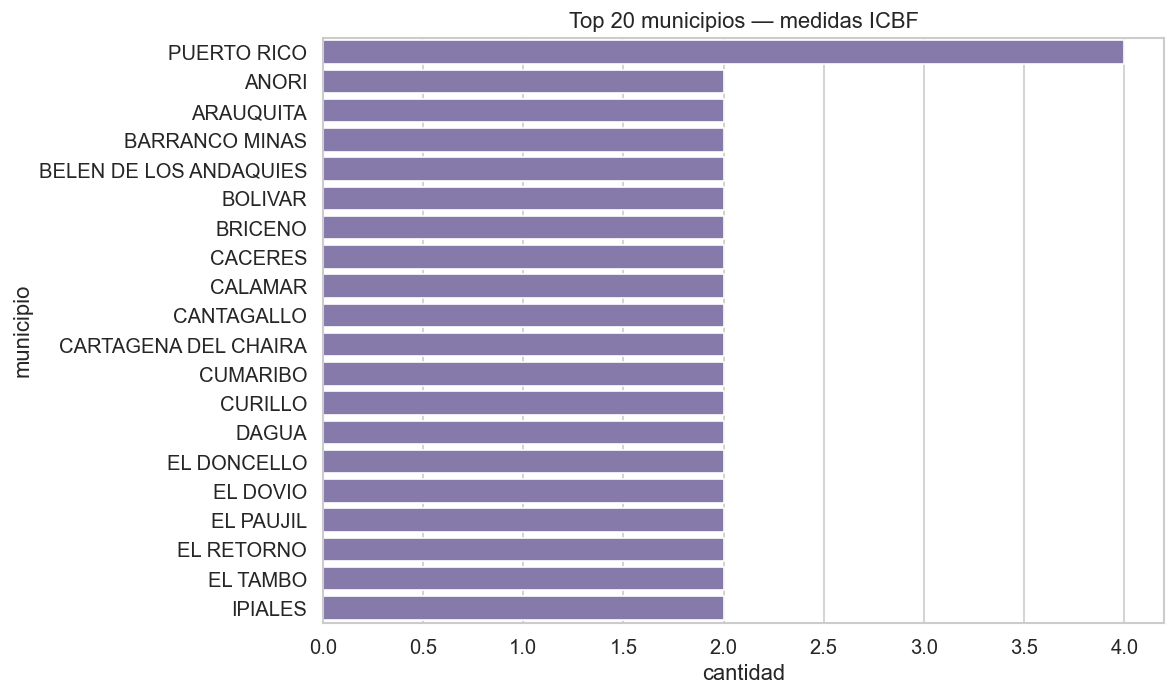

In [6]:
top_mun = df.groupby("municipio")["cantidad"].sum().nlargest(20).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_mun, y="municipio", x="cantidad", ax=ax, color="#8172B2")
ax.set_title("Top 20 municipios — medidas ICBF")
plt.tight_layout(); plt.show()


## 5 · Departamentos

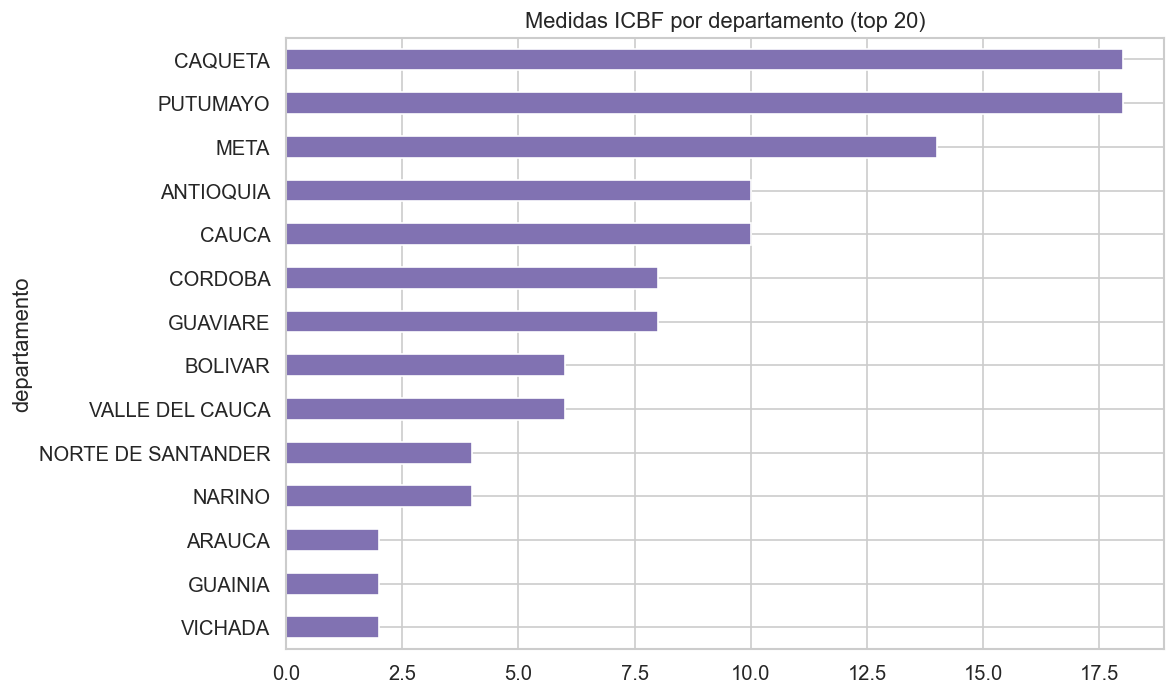

In [7]:
dep_cnt = df.groupby("departamento")["cantidad"].sum().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
dep_cnt.plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Medidas ICBF por departamento (top 20)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 7 · Exportar